In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import joblib

sns.set(style="darkgrid", rc={"figure.figsize": (12,6)})


In [8]:
def download_data(ticker="AAPL", period="10y", start=None, end=None):
    df = yf.download(ticker, period=period, start=start, end=end, auto_adjust=False)

    if df.empty:
        raise ValueError("No data returned from Yahoo Finance.")

    # Automatically choose correct column
    if "Adj Close" in df.columns:
        df = df[["Adj Close"]].rename(columns={"Adj Close": "price"})
    else:
        df = df[["Close"]].rename(columns={"Close": "price"})

    return df


In [9]:
def preprocess(df):
    df["returns"] = np.log(df["price"] / df["price"].shift(1))
    df = df.dropna()
    return df


In [10]:
def fit_hmm(returns, n_states=2):
    scaler = StandardScaler()
    X = scaler.fit_transform(returns.reshape(-1, 1))

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="full",
        n_iter=300,
        random_state=42
    )

    model.fit(X)

    hidden_states = model.predict(X)
    logprob, posteriors = model.score_samples(X)

    return {
        "model": model,
        "scaler": scaler,
        "states": hidden_states,
        "posteriors": posteriors,
        "log_likelihood": model.score(X)
    }


In [12]:
def plot_states(df, results, ticker="AAPL"):
    states = results["states"]
    df2 = df.iloc[-len(states):].copy()
    df2["state"] = states

    # ---- PRICE PLOT ----
    plt.figure(figsize=(14,6))
    for s in np.unique(states):
        plt.scatter(df2.index[df2.state==s], df2.price[df2.state==s], s=10, label=f"State {s}")
    plt.plot(df2.index, df2.price, alpha=0.3)
    plt.legend()
    plt.title(f"{ticker} Price with HMM States")
    plt.show()

    # ---- RETURNS PLOT ----
    plt.figure(figsize=(14,5))
    for s in np.unique(states):
        plt.scatter(df2.index[df2.state==s], df2.returns[df2.state==s], s=10, label=f"State {s}")
    plt.legend()
    plt.title(f"{ticker} Returns with Hidden States")
    plt.show()

    # ---- STATE TIMELINE ----
    plt.figure(figsize=(14,3))
    plt.plot(df2.index, df2.state, drawstyle="steps-post")
    plt.title("Hidden State Timeline")
    plt.show()


In [13]:
def predict_next_state(results):
    model = results["model"]
    last_post = results["posteriors"][-1]
    next_probs = last_post @ model.transmat_
    next_state = np.argmax(next_probs)

    print("Next State Prediction:", next_state)
    print("State probabilities:", next_probs)

    return next_state, next_probs


[*********************100%***********************]  1 of 1 completed


Preprocessing...
Training HMM...
Log Likelihood: -3192.700143586028
Plotting states...


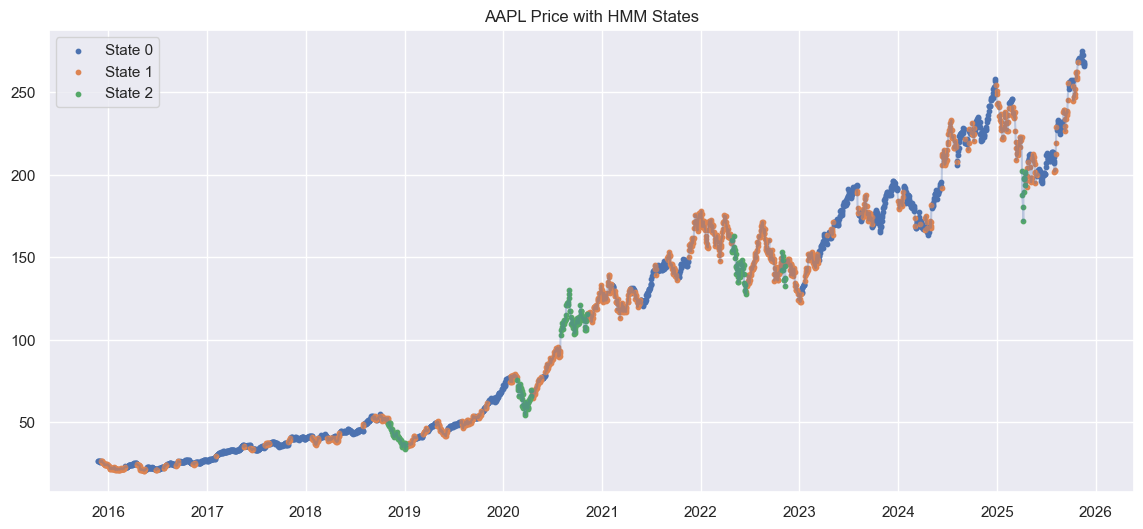

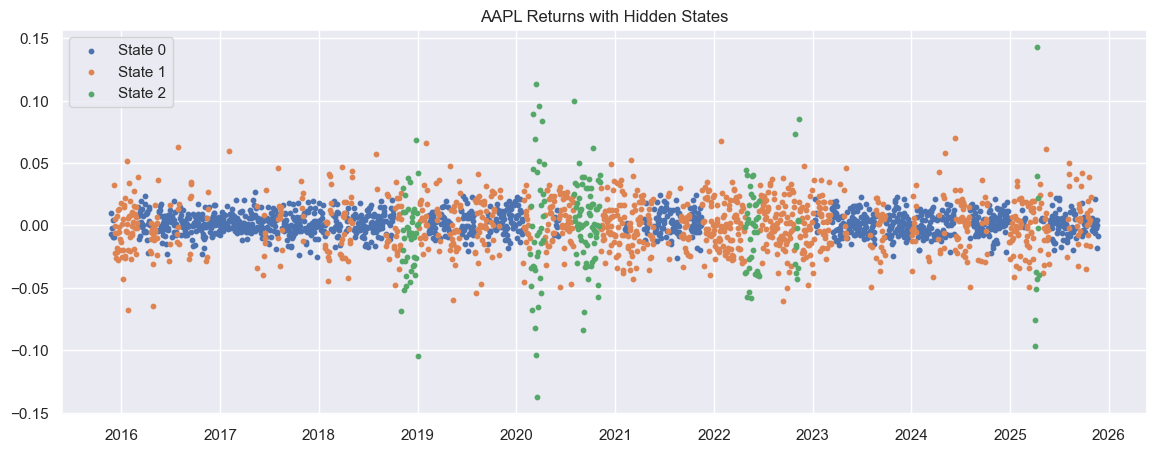

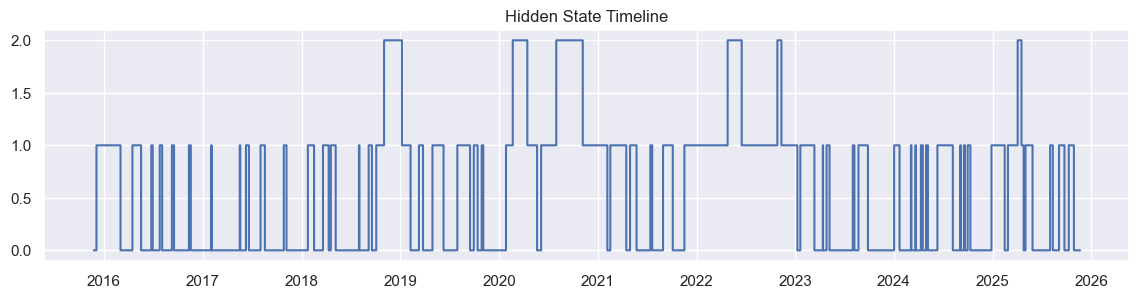

Predicting next state...
Next State Prediction: 0
State probabilities: [0.68019262 0.31482273 0.00498464]


(0, array([0.68019262, 0.31482273, 0.00498464]))

In [14]:
# Choose ticker and states
TICKER = "AAPL"
N_STATES = 3

print("Downloading data...")
df = download_data(TICKER, period="10y")

print("Preprocessing...")
df = preprocess(df)

print("Training HMM...")
results = fit_hmm(df["returns"].values, n_states=N_STATES)

print("Log Likelihood:", results["log_likelihood"])

print("Plotting states...")
plot_states(df, results, TICKER)

print("Predicting next state...")
predict_next_state(results)
